In [3]:
import os
import numpy as np
import librosa
from glob import glob
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
SR = 22050
DURATION = 3.0
SAMPLES = int(SR * DURATION)
N_MFCC = 40
HOP = 512
N_FFT = 2048
MAX_FRAMES = 130

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = r"E:/speech_emotion"


In [5]:
def map_emotion(folder):
    f = folder.lower()
    if "angry" in f: return "angry"
    if "happy" in f: return "happy"
    if "sad" in f: return "sad"
    if "fear" in f: return "fear"
    if "disgust" in f: return "disgust"
    if "neutral" in f: return "neutral"
    if "surprise" in f or "surprised" in f: return "surprise"
    return None


In [6]:
all_files = []
all_labels = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if not os.path.isdir(folder_path): continue
    
    emotion = map_emotion(folder)
    if emotion is None: continue
    
    wavs = glob(os.path.join(folder_path, "*.wav"))
    for f in wavs:
        all_files.append(f)
        all_labels.append(emotion)

print("Total files:", len(all_files))


Total files: 2800


In [7]:
le = LabelEncoder()
y_all = le.fit_transform(all_labels)

train_files, temp_files, y_train, y_temp = train_test_split(
    all_files, y_all, test_size=0.20, random_state=SEED, stratify=y_all)

val_files, test_files, y_val, y_test = train_test_split(
    temp_files, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))


Train: 2240
Val: 280
Test: 280


In [8]:
def load_audio(path, augment=False):
    audio, _ = librosa.load(path, sr=SR, mono=True)
    if len(audio) < SAMPLES:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))
    else:
        audio = audio[:SAMPLES]
    return audio

def extract_mfcc(audio):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        hop_length=HOP, n_fft=N_FFT
    )
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc)+1e-9)
    if mfcc.shape[1] < MAX_FRAMES:
        mfcc = np.pad(mfcc, ((0,0),(0,MAX_FRAMES - mfcc.shape[1])))
    return mfcc[:,:MAX_FRAMES]


In [9]:
def files_to_mfcc(files):
    X=[]
    for f in files:
        audio = load_audio(f)
        mf = extract_mfcc(audio)
        X.append(mf)
    return np.array(X)[..., np.newaxis]

X_train = files_to_mfcc(train_files)
X_val   = files_to_mfcc(val_files)
X_test  = files_to_mfcc(test_files)

print(X_train.shape, X_val.shape, X_test.shape)


(2240, 40, 130, 1) (280, 40, 130, 1) (280, 40, 130, 1)


In [10]:
from tensorflow.keras import layers, models

def build_model(input_shape, n_classes):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32,(3,3),padding='same',activation='relu')(inp)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64,(3,3),padding='same',activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    h,w,c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((w, h*c))(x)

    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model(X_train.shape[1:], len(le.classes_))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 32, 640)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │         360,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 388,487 (1.48 MB)

 Trainable params: 388,487 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    epochs=15,
    batch_size=32
)


Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.1665 - loss: 1.9408 - val_accuracy: 0.2214 - val_loss: 1.9151
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2112 - loss: 1.9063 - val_accuracy: 0.3929 - val_loss: 1.8421
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2853 - loss: 1.7942 - val_accuracy: 0.5464 - val_loss: 1.6074
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3737 - loss: 1.5936 - val_accuracy: 0.6250 - val_loss: 1.3072
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.4634 - loss: 1.3844 - val_accuracy: 0.6679 - val_loss: 1.0515
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5183 - loss: 1.2210 - val_accuracy: 0.8357 - val_loss: 0.7969
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6241 - loss: 1.0046 - val_accuracy: 0.9036 - val_loss: 0.6047
Epoch 8/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6996 - loss: 0.8256 - val_accuracy: 0.8571 - v

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9536 - loss: 0.1590
Final Test Accuracy: 0.9535714387893677
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        40
     disgust       0.95      0.95      0.95        40
        fear       0.89      1.00      0.94        40
       happy       0.95      0.88      0.91        40
     neutral       0.98      1.00      0.99        40
         sad       0.97      0.97      0.97        40
    surprise       0.97      0.88      0.92        40

    accuracy                           0.95       280
   macro avg       0.95      0.95      0.95       280
weighted avg       0.95      0.95      0.95       280



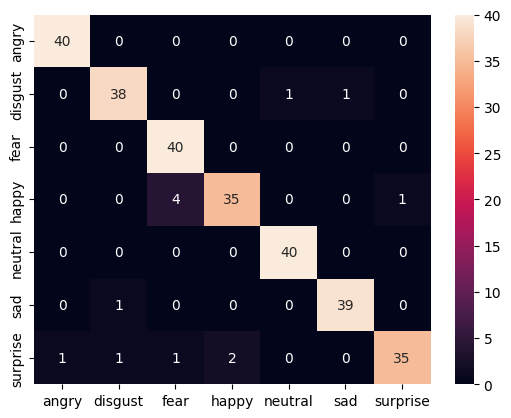

In [12]:
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.show()


In [13]:
model.save("speech_emotion_cnn_lstm_option1.h5")
print("Model saved!")


Model saved!


In [14]:
loaded_model = tf.keras.models.load_model("speech_emotion_cnn_lstm_option1.h5")
loaded_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 32, 640)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │         360,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 388,489 (1.48 MB)

 Trainable params: 388,487 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [15]:
pred = loaded_model.predict(X_test[:5])
print(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
[[1.0652197e-02 3.6423287e-04 9.8553747e-01 2.3061973e-03 2.0295754e-04
  3.9267240e-04 5.4434227e-04]
 [2.1286499e-04 2.1063099e-02 2.9020321e-03 2.1160180e-03 4.7118193e-03
  9.6841431e-01 5.7995401e-04]
 [3.1657249e-03 5.6275660e-01 1.9806186e-03 4.1930419e-03 5.7407683e-03
  4.2130119e-01 8.6203712e-04]
 [4.7340323e-03 3.9650383e-03 8.9819056e-05 1.2257822e-04 9.8919106e-01
  1.0151707e-03 8.8230899e-04]
 [6.9853766e-03 7.3476281e-04 5.6216202e-04 1.2219704e-02 9.3330191e-03
  3.9840517e-05 9.7012514e-01]]


In [16]:
# Get predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Print actual vs predicted for first 20 samples
for i in range(20):
    actual = le.inverse_transform([y_test[i]])[0]
    pred   = le.inverse_transform([y_pred[i]])[0]
    print(f"{i+1:02d}.  Actual: {actual:10}   Predicted: {pred}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
01.  Actual: fear         Predicted: fear
02.  Actual: sad          Predicted: sad
03.  Actual: sad          Predicted: disgust
04.  Actual: neutral      Predicted: neutral
05.  Actual: surprise     Predicted: surprise
06.  Actual: angry        Predicted: angry
07.  Actual: fear         Predicted: fear
08.  Actual: neutral      Predicted: neutral
09.  Actual: sad          Predicted: sad
10.  Actual: fear         Predicted: fear
11.  Actual: fear         Predicted: fear
12.  Actual: disgust      Predicted: disgust
13.  Actual: surprise     Predicted: surprise
14.  Actual: disgust      Predicted: disgust
15.  Actual: happy        Predicted: happy
16.  Actual: neutral      Predicted: neutral
17.  Actual: disgust      Predicted: disgust
18.  Actual: surprise     Predicted: surprise
19.  Actual: happy        Predicted: surprise
20.  Actual: happy        Predicted: happy
